<a href="https://colab.research.google.com/github/luckysinghal1008/-EDA_Optimising_NYC_Taxis_-lucky-/blob/main/Eye_for_blind_Starter_code_final_lucky_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EYE FOR BLIND
This notebook will be used to prepare the capstone project 'Eye for Blind'

In [ ]:
#Import all the required libraries
import glob

In [ ]:
!pip install kaggle

import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!kaggle datasets download -d adityajn105/flickr8k
!unzip flickr8k.zip



Streaming output truncated to the last 5000 lines.
  inflating: Images/2844963839_ff09cdb81f.jpg  
  inflating: Images/2845246160_d0d1bbd6f0.jpg  
  inflating: Images/2845691057_d4ab89d889.jpg  
  inflating: Images/2845845721_d0bc113ff7.jpg  
  inflating: Images/2846037553_1a1de50709.jpg  
  inflating: Images/2846785268_904c5fcf9f.jpg  
  inflating: Images/2846843520_b0e6211478.jpg  
  inflating: Images/2847514745_9a35493023.jpg  
  inflating: Images/2847615962_c330bded6e.jpg  
  inflating: Images/2847859796_4d9cb0d31f.jpg  
  inflating: Images/2848266893_9693c66275.jpg  
  inflating: Images/2848571082_26454cb981.jpg  
  inflating: Images/2848895544_6d06210e9d.jpg  
  inflating: Images/2848977044_446a31d86e.jpg  
  inflating: Images/2849194983_2968c72832.jpg  
  inflating: Images/2850719435_221f15e951.jpg  
  inflating: Images/2851198725_37b6027625.jpg  
  inflating: Images/2851304910_b5721199bc.jpg  
  inflating: Images/2851931813_eaf8ed7be3.jpg  
  inflating: Images/2852982055_8112d0

Let's read the dataset

## Data understanding
1.Import the dataset and read image & captions into two seperate variables

2.Visualise both the images & text present in the dataset

3.Create a dataframe which summarizes the image, path & captions as a dataframe

4.Create a list which contains all the captions & path

5.Visualise the top 30 occuring words in the captions



In [ ]:
#Import the dataset and read the image into a seperate variable

images='/content/Images'

all_imgs = glob.glob(images + '/*.jpg',recursive=True)
print("The total images present in the dataset: {}".format(len(all_imgs)))

The total images present in the dataset: 8091


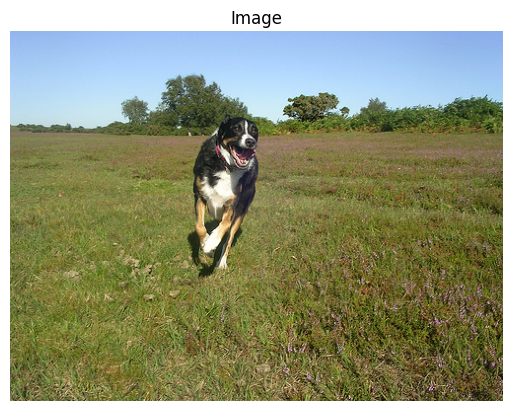

Captions for image: 1119418776_58e4b93eac.jpg

1. black and white dog is running through the field .
2. black , brown and white dog running through a field ."
3. brown , black and white dog is running through a large field with its mouth open ."
4. dog running in a field .
5. dog with its mouth open running through a field torwards the camera .


In [ ]:
#Visualise both the images & text present in the dataset
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Paths
IMAGE_DIR = "/content/Images"
CAPTION_FILE = "/content/captions.txt"

# Pick a random image
image_name = random.choice(os.listdir(IMAGE_DIR))
image_path = os.path.join(IMAGE_DIR, image_name)

# Load image
image = Image.open(image_path).convert("RGB")

# Read captions
captions = []
with open(CAPTION_FILE, 'r') as f:
    for line in f:
        # Each line starts with image_name + #index
        if line.startswith(image_name.split('.')[0]):  # ignore extension
            caption = line.strip().split('\t')[-1] if '\t' in line else line.strip().split(' ', 1)[-1]
            captions.append(caption)

# Plot image
plt.imshow(image)
plt.axis("off")
plt.title("Image")
plt.show()

# Print captions
print(f"Captions for image: {image_name}\n")
for i, cap in enumerate(captions, 1):
    print(f"{i}. {cap}")




In [ ]:
#Import the dataset and read the text file into a seperate variable

def load_doc(filename):
    # Open the file in read mode
    with open(filename, 'r') as file:
        text = file.read()  # Read entire content as a string
    return text

# Path to your captions file
CAPTION_FILE = "/content/captions.txt"

# Load the document
doc = load_doc(CAPTION_FILE)

# Preview first 300 characters
print(doc[:300])

image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing


Create a dataframe which summarizes the image, path & captions as a dataframe

Each image id has 5 captions associated with it therefore the total dataset should have 40455 samples.

In [ ]:
import pandas as pd
import os

all_img_id = []
all_img_vector = []
annotations = []

lines = doc.strip().split("\n")

# skip header
for line in lines[1:]:
    image_name, caption = line.split(",", 1)   # split only first comma

    image_name = image_name.strip()
    caption = caption.strip().lower()

    img_path = os.path.join("/content/Images", image_name)

    all_img_id.append(image_name)
    all_img_vector.append(img_path)
    annotations.append(caption)

df = pd.DataFrame({
    "ID": all_img_id,
    "Path": all_img_vector,
    "Captions": annotations
})

df.head()



,ID,Path,Captions
0,1000268201_693b08cb0e.jpg,/content/Images/1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,/content/Images/1000268201_693b08cb0e.jpg,a girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,/content/Images/1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,/content/Images/1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,/content/Images/1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...


In [ ]:
#Create a list which contains all the captions

annotations = df["Captions"].astype(str).tolist()#write your code here
import string

#translator = str.maketrans('', '', string.punctuation)

annotations = [
    caption.lower()
    for caption in annotations
]

annotations = [f"<start> {c.strip()} <end>" for c in annotations]
annotations[:10]

#add the <start> & <end> token to all those captions as well

#Create a list which contains all the path to the images
all_img_path=list(df['Path'])#write your code here
all_img_path[:10]
print("Total captions present in the dataset: "+ str(len(annotations)))
print("Total images present in the dataset: " + str(len(all_img_path)))

Total captions present in the dataset: 40455
Total images present in the dataset: 40455


In [ ]:
#Create the vocabulary & the counter for the captions
from collections import Counter
vocabulary=[] #write your code here
for caption in annotations:
    vocabulary.extend(caption.lower().split())

# Create word frequency counter
val_count = Counter(vocabulary)


most_common_5000 = val_count.most_common(5000)
val_count.most_common(30)

[('a', 61752),
 ('<start>', 40455),
 ('<end>', 40455),
 ('.', 34212),
 ('in', 18965),
 ('the', 18249),
 ('on', 10732),
 ('is', 9345),
 ('and', 8851),
 ('dog', 8126),
 ('with', 7761),
 ('man', 7238),
 ('of', 6712),
 ('two', 5224),
 ('white', 3935),
 ('black', 3825),
 ('boy', 3561),
 ('are', 3504),
 ('woman', 3385),
 ('girl', 3320),
 (',', 3210),
 ('to', 3173),
 ('wearing', 3061),
 ('at', 2905),
 ('people', 2856),
 ('water', 2779),
 ('red', 2672),
 ('young', 2607),
 ('brown', 2549),
 ('an', 2399)]

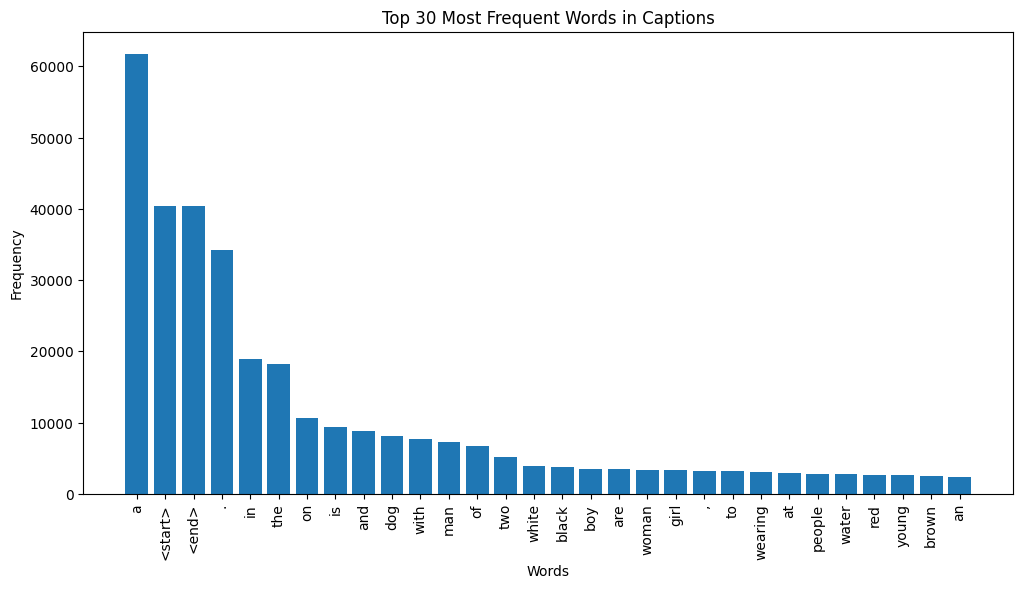

In [ ]:
#Visualise the top 30 occuring words in the captions
import matplotlib.pyplot as plt

# Get top 30 most common words
top_30 = val_count.most_common(30)

# Separate words and counts
words = [item[0] for item in top_30]
counts = [item[1] for item in top_30]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Frequent Words in Captions")
plt.show()

#write your code here

## Pre-Processing the captions
1.Create the tokenized vectors by tokenizing the captions fore ex :split them using spaces & other filters.
This gives us a vocabulary of all of the unique words in the data. Keep the total vocaublary to top 5,000 words for saving memory.

2.Replace all other words with the unknown token "UNK" .

3.Create word-to-index and index-to-word mappings.

4.Pad all sequences to be the same length as the longest one.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 5000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<unk>",   # unknown token
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(annotations)   # annotations = list of captions
tokenizer.index_word[0] = '<pad>'
tokenizer.word_index['<pad>'] = 0
sequences = tokenizer.texts_to_sequences(annotations)


In [ ]:
# Create word-to-index and index-to-word mappings.
word_to_index = tokenizer.word_index
index_to_word = tokenizer.index_word

print("Vocab size (including <pad>):", len(word_to_index))
print("Sample mapping:", list(word_to_index.items())[:10])
#your code here

Vocab size (including <pad>): 8497
Sample mapping: [('<unk>', 1), ('a', 2), ('<start>', 3), ('<end>', 4), ('in', 5), ('the', 6), ('on', 7), ('is', 8), ('and', 9), ('dog', 10)]


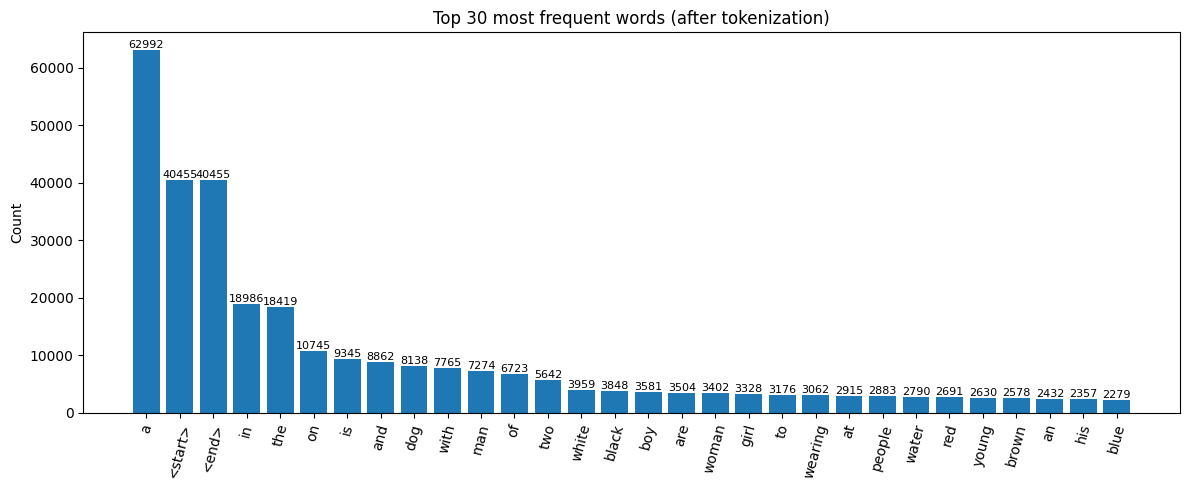

In [ ]:
# Create a word count of your tokenizer to visulize the Top 30 occuring words after text processing
from collections import Counter
import matplotlib.pyplot as plt

tok_counts = tokenizer.word_counts  # dict-like: word -> count
top_k = 30
most_common = Counter(tok_counts).most_common(top_k)

words = [w for w, c in most_common]
counts = [c for w, c in most_common]

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color="#1f77b4")
plt.xticks(rotation=75)
plt.title("Top 30 most frequent words (after tokenization)")
plt.ylabel("Count")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, str(int(h)), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Pad each vector to the max_length of the captions ^ store it to a vairable
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = max(len(seq) for seq in sequences)

encoded_captions = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',value=0.0
)
print("The shape of Caption vector is :" + str(encoded_captions.shape))

The shape of Caption vector is :(40455, 39)


## Pre-processing the images

1.Resize them into the shape of (299, 299)

3.Normalize the image within the range of -1 to 1, such that it is in correct format for InceptionV3.

### FAQs on how to resize the images::
* Since you have a list which contains all the image path, you need to first convert them to a dataset using <i>tf.data.Dataset.from_tensor_slices</i>. Once you have created a dataset consisting of image paths, you need to apply a function to the dataset which will apply the necessary preprocessing to each image.
* This function should resize them and also should do the necessary preprocessing that it is in correct format for InceptionV3.


In [ ]:
#write your code here to create the dataset consisting of image paths
import tensorflow as tf

image_path_dataset = tf.data.Dataset.from_tensor_slices(all_img_path)
print(image_path_dataset)
for p in image_path_dataset.take(3):
    print(p.numpy().decode('utf-8'))


<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>
/content/Images/1000268201_693b08cb0e.jpg
/content/Images/1000268201_693b08cb0e.jpg
/content/Images/1000268201_693b08cb0e.jpg


In [ ]:
#write your code here for creating the function. This function should return images & their path
from tensorflow.keras.applications.inception_v3 import preprocess_input
def load_image(image_path):
    #write your pre-processing steps here
    # 1. Read image from disk
    img = tf.io.read_file(image_path)

    # 2. Decode JPEG
    img = tf.image.decode_jpeg(img, channels=3)

    # 3. Resize to (299, 299)
    img = tf.image.resize(img, (299, 299))

    # 4. Convert to float32
    img = tf.cast(img, tf.float32)

    # 5. Normalize to [-1, 1] for InceptionV3
    img = preprocess_input(img)

    return img, image_path
img, path = load_image(all_img_path[0])
print(img.shape)
print(tf.reduce_min(img), tf.reduce_max(img))


(299, 299, 3)
tf.Tensor(-1.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [ ]:
#write your code here for applying the function to the image path dataset, such that the transformed dataset should contain images & their path

image_dataset = image_path_dataset.map(load_image).batch(32)



## Load the pretrained Imagenet weights of Inception net V3

1.To save the memory(RAM) from getting exhausted, extract the features of the images using the last layer of pre-trained model. Including this as part of training will lead to higher computational time.

2.The shape of the output of this layer is 8x8x2048.

3.Use a function to extract the features of each image in the train & test dataset such that the shape of each image should be (batch_size, 8*8, 2048)



In [ ]:
image_model = tf.keras.applications.InceptionV3(include_top=False,weights='imagenet')

new_input = image_model.input#write code here to get the input of the image_model
hidden_layer =image_model.layers[-1].output #write code here to get the output of the image_model

image_features_extract_model=tf.keras.Model(
    inputs=new_input,
    outputs=hidden_layer
)

 #build the final model using both input & output layer

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# write the code to apply the feature_extraction model to your earlier created dataset which contained images & their respective paths
# Once the features are created, you need to reshape them such that feature shape is in order of (batch_size, 8*8, 2048)

def extract_features(img_batch):
    features = image_features_extract_model(img_batch)
    features = tf.reshape(features, (features.shape[0], -1, 2048))
    return features
import os
import numpy as np

save_dir = "/content/features"
os.makedirs(save_dir, exist_ok=True)

for img_batch, path_batch in image_dataset:

    batch_features = extract_features(img_batch)   # only pass images

    for bf, p in zip(batch_features, path_batch):

        path = p.numpy().decode("utf-8")

        file_name = os.path.basename(path)

        save_path = os.path.join(save_dir, file_name)

        np.save(save_path, bf.numpy())



### FAQs on how to store the features:
* You can store the features using a dictionary with the path as the key and values as the feature extracted by the inception net v3 model OR
* You can store using numpy(np.save) to store the resulting vector.

## Dataset creation
1.Apply train_test_split on both image path & captions to create the train & test list. Create the train-test spliit using 80-20 ratio & random state = 42

2.Create a function which maps the image path to their feature.

3.Create a builder function to create train & test dataset & apply the function created earlier to transform the dataset

2.Make sure you have done Shuffle and batch while building the dataset

3.The shape of each image in the dataset after building should be (batch_size, 8*8, 2048)

4.The shape of each caption in the dataset after building should be(batch_size, max_len)


In [ ]:
#write your code here
from sklearn.model_selection import train_test_split
#path_train, path_test, cap_train, cap_test = train_test_split( #your code goes here)
path_train, path_test, cap_train, cap_test = train_test_split(
    all_img_path,
    encoded_captions,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training data for images: " + str(len(path_train)))
print("Testing data for images: " + str(len(path_test)))
print("Training data for Captions: " + str(len(cap_train)))
print("Testing data for Captions: " + str(len(cap_test)))

Training data for images: 32364
Testing data for images: 8091
Training data for Captions: 32364
Testing data for Captions: 8091


In [ ]:
# Create a function which maps the image path to their feature.
# This function will take the image_path & caption and return it's feature & respective caption.

def map_func(img_name, cap):
      # Convert tensor path → string
    #img_name = img_name.numpy().decode("utf-8")
    # Extract file name and build .npy path
    file_name = os.path.basename(img_name)
    feature_path = os.path.join("/content/features", file_name + ".npy")

    # Load saved features
    img_tensor = np.load(feature_path)
    img_tensor = tf.convert_to_tensor(img_tensor, dtype=tf.float32)# write your code here to extract the features from the dictionary stored earlier
    return img_tensor, cap
img_tensor, caption = map_func(path_train[0], cap_train[0])

print("Feature shape:",img_tensor)
print("Caption:", caption)


Feature shape: tf.Tensor(
[[0.         0.         0.         ... 0.         0.         0.5292745 ]
 [0.         0.         0.         ... 0.         0.         0.19399607]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         1.9285461  1.2831069  ... 1.7450343  1.6707141  0.        ]
 [0.         0.47135636 1.0583581  ... 1.2710838  1.4578794  0.        ]
 [0.         0.         0.         ... 0.8521956  0.9630654  0.        ]], shape=(64, 2048), dtype=float32)
Caption: [  3   2  12   9   2  10  18  39   7   2 141 154 109 554  47  21   6 171
   4   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0]


### FAQs on how to load the features:
* You can load the features using the dictionary created earlier OR
* You can store using numpy(np.load) to load the feature vector.

In [ ]:
# create a builder function to create dataset which takes in the image path & captions as input
# This function should transform the created dataset(img_path,cap) to (features,cap) using the map_func created earlier

def gen_dataset(img_paths, captions, batch_size=32):

        # Create dataset from image paths and captions
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, captions))
    dataset=dataset.shuffle(1000)

    # Map image path → feature using map_func
    def wrapper(img, cap):

        img = img.numpy().decode("utf-8")
        cap = cap.numpy()

        return map_func(img, cap)

    def tf_map_func(img, cap):

        img, cap = tf.py_function(
            func=wrapper,
            inp=[img, cap],
            Tout=[tf.float32, tf.int32]
        )

        img.set_shape((64, 2048))
        cap.set_shape((max_len,))

        return img, cap
    dataset = dataset.map(
        tf_map_func,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch + Prefetch for performance
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)# your code goes here to create the dataset & transform it


    return dataset



In [ ]:
train_dataset=gen_dataset(path_train,cap_train)
test_dataset=gen_dataset(path_test,cap_test)

In [ ]:
sample_img_batch, sample_cap_batch = next(iter(train_dataset))

print(sample_img_batch.shape)  #(batch_size, 8*8, 2048)
print(sample_cap_batch.shape) #(batch_size,max_len)




(32, 64, 2048)
(32, 39)


In [ ]:
len(path_test)

8091

## Model Building
1.Set the parameters

2.Build the Encoder, Attention model & Decoder

In [ ]:
embedding_dim = 256
units = 512
vocab_size = 5001
train_num_steps =len(path_train) // 32
test_num_steps = len(path_test) // 32

### Encoder

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
class Encoder(Model):
    def __init__(self,embed_dim):
        super(Encoder, self).__init__()
        self.dense =Dense(embed_dim, activation='relu') #build your Dense layer with relu activation
        #self.dropout = tf.keras.layers.Dropout(0.3)
    def call(self, features):
        features = self.dense(features) # extract the features from the image shape: (batch, 8*8, embed_dim)
        #features = self.dropout(features)
        return features

In [ ]:
encoder=Encoder(embedding_dim)

In [ ]:
sample_out = encoder(sample_img_batch)

print(sample_out.shape)

(32, 64, 256)


### Attention model

In [ ]:
class Attention_model(Model):
    def __init__(self, units):
        super(Attention_model, self).__init__()
        self.W1 =tf.keras.layers.Dense(units) #build your Dense layer
        self.W2 = tf.keras.layers.Dense(units)#build your Dense layer
        self.V =tf.keras.layers.Dense(1) #build your final Dense layer with unit 1
        self.units=units
        #self.dropout = tf.keras.layers.Dropout(0.3)



    def call(self, features, hidden):
        #features shape: (batch_size, 8*8, embedding_dim)
        # hidden shape: (batch_size, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)  # Expand the hidden shape to shape: (batch_size, 1, hidden_size)
        # Compute attention score
        score = self.W1(features) + self.W2(hidden_with_time_axis)
        score = self.V(tf.nn.tanh(score))# build your score funciton to shape: (batch_size, 8*8, units)
        attention_weights =tf.nn.softmax(score, axis=1) # extract your attention weights with shape: (batch_size, 8*8, 1)
        context_vector = attention_weights * features #shape: create the context vector with shape (batch_size, 8*8,embedding_dim)
        context_vector = tf.reduce_sum(context_vector, axis=1)# reduce the shape to (batch_size, embedding_dim)
        #context_vector = self.dropout(context_vector)

        return context_vector, attention_weights

### Decoder

In [ ]:
class Decoder(Model):
    def __init__(self, embed_dim, units, vocab_size):
        super(Decoder, self).__init__()
        self.units=units
        self.attention = Attention_model(units)#iniitalise your Attention model with units
        self.embed = tf.keras.layers.Embedding(vocab_size, embed_dim)#build your Embedding layer
        #self.dropout1 = tf.keras.layers.Dropout(0.3)
        self.gru = tf.keras.layers.GRU(self.units,return_sequences=True,return_state=True,recurrent_initializer='glorot_uniform',reset_after=False)
        #self.dropout2 = tf.keras.layers.Dropout(0.4)

        self.d1 = tf.keras.layers.Dense(self.units, activation="relu")#build your Dense layer
        #self.fc_dropout = tf.keras.layers.Dropout(0.3)
        self.d2 = tf.keras.layers.Dense(vocab_size)#build your Dense layer


    def call(self,x,features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)#create your context vector & attention weights from attention model
        embed =  self.embed(x)# embed your input to shape: (batch_size, 1, embedding_dim)
        #embed = self.dropout1(embed)
        context_vector = tf.expand_dims(context_vector, 1)
        #context_vector = self.attn_dropout(context_vector)


        embed = tf.concat([embed,context_vector],axis=-1) # Concatenate your input with the context vector from attention layer. Shape: (batch_size, 1, embedding_dim + embedding_dim)

        output, state = self.gru(embed) # Extract the output & hidden state from GRU layer. Output shape : (batch_size, max_length, hidden_size)
        #output = self.dropout2(output)
        output = self.d1(output)
        #output = self.fc_dropout(output)
        output = tf.reshape(output, (-1, output.shape[2])) # shape : (batch_size * max_length, hidden_size)
        output = self.d2(output) # shape : (batch_size * max_length, vocab_size)

        return output,state, attention_weights

    def init_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

In [ ]:
decoder=Decoder(embedding_dim, units, vocab_size)

In [ ]:
features=encoder(sample_img_batch)
sample_cap_batch.shape
hidden = decoder.init_state(batch_size=sample_cap_batch.shape[0])
dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * sample_cap_batch.shape[0], 1)

predictions, hidden_out, attention_weights= decoder(dec_input, features, hidden)
print('Feature shape from Encoder: {}'.format(features.shape)) #(batch, 8*8, embed_dim)
print('Predcitions shape from Decoder: {}'.format(predictions.shape)) #(batch,vocab_size)
print('Attention weights shape from Decoder: {}'.format(attention_weights.shape)) #(batch, 8*8, 1)





Feature shape from Encoder: (32, 64, 256)
Predcitions shape from Decoder: (32, 5001)
Attention weights shape from Decoder: (32, 64, 1)


## Model training & optimization
1.Set the optimizer & loss object

2.Create your checkpoint path

3.Create your training & testing step functions

4.Create your loss function for the test dataset

In [ ]:

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
 #define the optimizer
loss_object =tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
) #define your loss object

In [ ]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)

In [ ]:
checkpoint_path = "./checkpoints/train"

ckpt = tf.train.Checkpoint(encoder=encoder,
                           decoder=decoder,
                           optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

In [ ]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 2048), dtype=tf.float32, name=None), TensorSpec(shape=(None, 39), dtype=tf.int32, name=None))>

* While creating the training step for your model, you will apply Teacher forcing.
* Teacher forcing is a technique where the target/real word is passed as the next input to the decoder instead of previous prediciton.

In [ ]:
@tf.function
def train_step(img_tensor, target):
    loss = 0.0
    hidden = decoder.init_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index["<start>"]] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)#write your code here to do the training steps
        for i in tf.range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)

        avg_loss = loss / tf.cast((target.shape[1] - 1), tf.float32)

    trainable_vars = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    optimizer.apply_gradients(zip(gradients, trainable_vars))

    return loss, avg_loss

* While creating the test step for your model, you will pass your previous prediciton as the next input to the decoder.

In [ ]:
@tf.function
def test_step(img_tensor, target):
    loss = 0.0

    #write your code here to do the testing steps
    hidden = decoder.init_state(batch_size=target.shape[0])

    dec_input = tf.expand_dims(
        [tokenizer.word_index["<start>"]] * target.shape[0], 1
    )

    features = encoder(img_tensor)

    for i in tf.range(1, target.shape[1]):

        predictions, hidden, _ = decoder(dec_input, features, hidden)

        loss += loss_function(target[:, i], predictions)
        predicted_id = tf.argmax(predictions, axis=1, output_type=tf.int32)
        dec_input = tf.expand_dims(predicted_id, 1)

    avg_loss = loss / tf.cast((target.shape[1] - 1), tf.float32)

    return loss, avg_loss

In [ ]:
def test_loss_cal(test_dataset):
    total_loss = 0.0

    #write your code to get the average loss result on your test data
    for (batch, (img_tensor, target)) in enumerate(test_dataset):
        _, t_loss = test_step(img_tensor, target)
        total_loss += t_loss

    avg_test_loss = total_loss / tf.cast(test_num_steps, tf.float32)
    return avg_test_loss

In [ ]:
loss_plot = []
test_loss_plot = []
EPOCHS = 15
from tqdm import tqdm
import time

best_test_loss=100
for epoch in tqdm(range(0, EPOCHS)):
    start = time.time()
    total_loss = 0

    for (batch, (img_tensor, target)) in enumerate(train_dataset):
        batch_loss, t_loss = train_step(img_tensor, target)
        total_loss += t_loss
        avg_train_loss=total_loss / train_num_steps

    loss_plot.append(avg_train_loss)
    test_loss = test_loss_cal(test_dataset)
    test_loss_plot.append(test_loss)

    print ('For epoch: {}, the train loss is {:.3f}, & test loss is {:.3f}'.format(epoch+1,avg_train_loss,test_loss))
    print ('Time taken for 1 epoch {} sec\n'.format(time.time() - start))

    if test_loss < best_test_loss:
        print('Test loss has been reduced from %.3f to %.3f' % (best_test_loss, test_loss))
        best_test_loss = test_loss
        ckpt_manager.save()


  0%|          | 0/15 [00:00<?, ?it/s]

For epoch: 1, the train loss is 1.410, & test loss is 1.796
Time taken for 1 epoch 262.1524455547333 sec

Test loss has been reduced from 100.000 to 1.796


 13%|█▎        | 2/15 [08:50<57:35, 265.81s/it]  

For epoch: 2, the train loss is 1.114, & test loss is 1.918
Time taken for 1 epoch 268.1946020126343 sec



 20%|██        | 3/15 [13:02<51:55, 259.59s/it]

...

For epoch: 13, the train loss is 0.604, & test loss is 2.388
Time taken for 1 epoch 288.66786336898804 sec



 93%|█████████▎| 14/15 [1:03:08<04:43, 283.61s/it]

For epoch: 14, the train loss is 0.580, & test loss is 2.484
Time taken for 1 epoch 302.86718225479126 sec



100%|██████████| 15/15 [1:07:56<00:00, 271.79s/it]

For epoch: 15, the train loss is 0.557, & test loss is 2.484
Time taken for 1 epoch 288.53528690338135 sec



In [ ]:
print("Latest checkpoint:", ckpt_manager.latest_checkpoint)



Latest checkpoint: ./checkpoints/train/ckpt-1


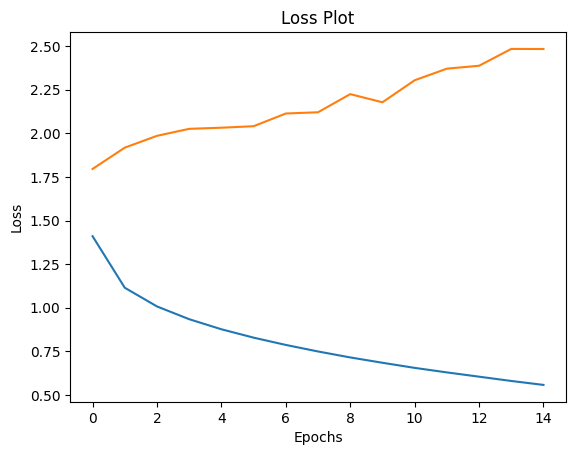

In [ ]:
plt.plot(loss_plot)
plt.plot(test_loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

#### NOTE:
* Since there is a difference between the train & test steps ( Presence of teacher forcing), you may observe that the train loss is decreasing while your test loss is not.
* This doesn't mean that the model is overfitting, as we can't compare the train & test results here, as both approach is different.
* Also, if you want to achieve better results you can run it more epochs, but the intent of this capstone is to give you an idea on how to integrate attention mechanism with E-D architecture for images. The intent is not to create the state of art model.

## Model Evaluation
1.Define your evaluation function using greedy search

2.Define your evaluation function using beam search ( optional)

3.Test it on a sample data using BLEU score

### Greedy Search

In [ ]:
def evaluate(image):
    max_length=39
    attention_features_shape=64
    attention_plot = np.zeros((max_length, attention_features_shape))

    hidden = decoder.init_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0) #process the input image to desired format before extracting features
    img_tensor_val =image_features_extract_model(temp_input) # Extract features using our feature extraction model
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))

    features = encoder(img_tensor_val)# extract the features by passing the input to encoder

    dec_input = tf.expand_dims([word_to_index['<start>']], 0)
    result = []
    used_words = []

    for i in range(max_length):
        predictions, hidden, attention_weights =  decoder(dec_input, features, hidden)# get the output from decoder


        attention_plot[i] = tf.reshape(attention_weights, (-1, )).numpy()

        predicted_id = int(tf.argmax(predictions[0]).numpy())#extract the predicted id(embedded value) which carries the max value
        #map the id to the word from tokenizer and append the value to the result list
        preds = predictions[0].numpy()
        predicted_id = int(np.argmax(preds))
        predicted_word = index_to_word[predicted_id]
        if predicted_word == '<end>':
            return result, attention_plot,predictions
        result.append(predicted_word)

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot,predictions


### Beam Search(optional)

In [ ]:
def beam_evaluate(image, beam_index=5):

    max_length = 39

    # Extract image features
    hidden = decoder.init_state(batch_size=1)

    temp_input = tf.expand_dims(load_image(image)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(
        img_tensor_val,
        (img_tensor_val.shape[0], -1, img_tensor_val.shape[3])
    )

    features = encoder(img_tensor_val)

    # Start token
    start_token = word_to_index['<start>']
    dec_input = tf.expand_dims([start_token], 0)

    # Beam stores: (sequence, score, hidden_state)
    sequences = [([start_token], 0.0, hidden)]

    for _ in range(max_length):

        all_candidates = []

        for seq, score, hidden_state in sequences:

            dec_input = tf.expand_dims([seq[-1]], 0)

            predictions, hidden_new, _ = decoder(
                dec_input, features, hidden_state
            )

            predictions = tf.nn.log_softmax(predictions[0]).numpy()

            # Get top beam_index predictions
            top_k_ids = np.argsort(predictions)[-beam_index:]

            for idx in top_k_ids:
                candidate_seq = seq + [idx]
                length_penalty = ((5 + len(candidate_seq)) / 6) ** 0.7
                candidate_score = (score + predictions[idx]) / length_penalty
                all_candidates.append(
                    (candidate_seq, candidate_score, tf.identity(hidden_new))
                )

        # Sort by score (highest first)
        ordered = sorted(
            all_candidates,
            key=lambda tup: tup[1],
            reverse=True
        )


        sequences = ordered[:beam_index]

    # Choose best sequence
    best_seq = sequences[0][0]

    # Convert ids to words (skip <start>)
    final_caption = []
    for idx in best_seq[1:]:
        word = index_to_word[idx]
        if word == '<end>':
            break
        final_caption.append(word)

    return final_caption




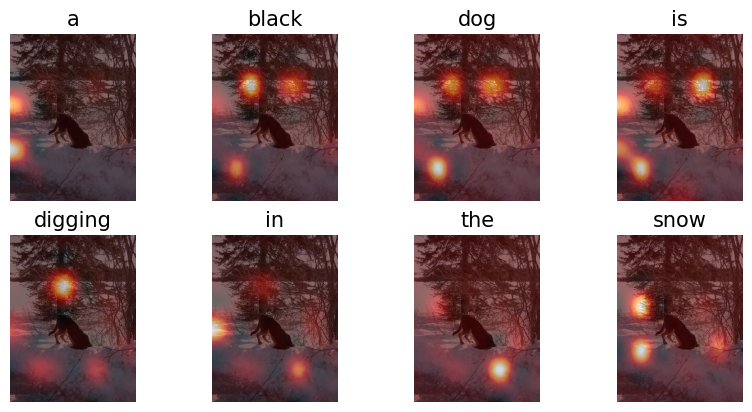

In [ ]:
def plot_attmap(caption, weights, image):

    fig = plt.figure(figsize=(10, 10))
    temp_img = np.array(Image.open(image))

    len_cap = len(caption)
    for cap in range(len_cap):
        weights_img = np.reshape(weights[cap], (8,8))
        weights_img = np.array(Image.fromarray(weights_img).resize((224, 224), Image.LANCZOS))

        ax = fig.add_subplot(len_cap//2, len_cap//2, cap+1)
        ax.set_title(caption[cap], fontsize=15)

        img=ax.imshow(temp_img)

        ax.imshow(weights_img, cmap='gist_heat', alpha=0.6,extent=img.get_extent())
        ax.axis('off')
    plt.subplots_adjust(hspace=0.2, wspace=0.2)
    plt.show()
image_path='/content/Images/413231421_43833a11f5.jpg'
result, attention_plot, _ = evaluate(image_path)

plot_attmap(result, attention_plot, image_path)


In [ ]:
from nltk.translate.bleu_score import sentence_bleu

In [ ]:
def filt_text(text):
    filt=['<start>','<unk>','<end>']
    temp= text.split()
    [temp.remove(j) for k in filt for j in temp if k==j]
    text=' '.join(temp)
    return text


Random id: 1449
BLEU-1: 47.42
BLEU-2: 37.07
BLEU-3: 26.27
BLEU-4: 18.92

Real Caption: a girl wearing a red and multi colored bikini is laying on her back in shallow water
Prediction Caption: a girl in a red dress is laying on her head


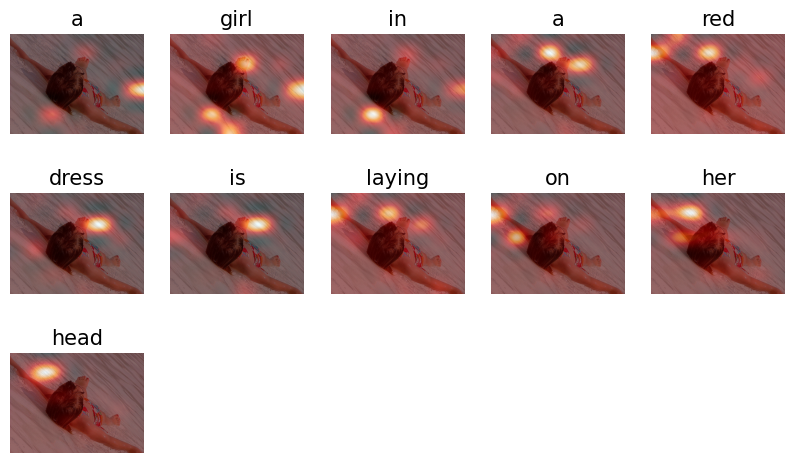

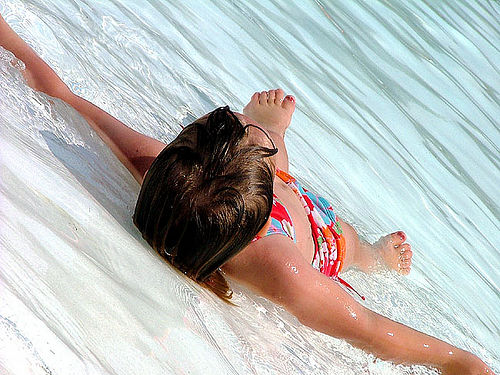

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import re
from PIL import Image

rid = np.random.randint(0, len(path_test))
print("Random id:", rid)

test_image = path_test[rid]

#test_image = './images/413231421_43833a11f5.jpg'
#real_caption = '<start> black dog is digging in the snow <end>'

def clean_caption(words):
    words = [w.lower() for w in words if w not in ["<start>", "<end>"]]
    sentence = " ".join(words)
    sentence = re.sub(r"[^a-z\s]", "", sentence)  # remove punctuation
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# ------------------ REAL CAPTION ------------------
real_tokens = [i for i in cap_test[rid] if i != 0]

real_words = []
for i in real_tokens:
    word = tokenizer.index_word.get(i)
    if word:
        real_words.append(word)

real_caption = clean_caption(real_words)

# ------------------ PREDICTED CAPTION ------------------
result, attention_plot, _ = evaluate(test_image)

pred_caption = clean_caption(result)

# ------------------ BLEU SCORE ------------------
smooth = SmoothingFunction().method1

if len(pred_caption) == 0:
    bleu1 = bleu2 = bleu3 = bleu4 = 0
else:
    reference = [real_caption.split()]
    candidate = pred_caption.split()

    bleu1 = sentence_bleu(reference, candidate,
                          weights=(1, 0, 0, 0),
                          smoothing_function=smooth)

    bleu2 = sentence_bleu(reference, candidate,
                          weights=(0.5, 0.5, 0, 0),
                          smoothing_function=smooth)

    bleu3 = sentence_bleu(reference, candidate,
                          weights=(0.33, 0.33, 0.33, 0),
                          smoothing_function=smooth)

    bleu4 = sentence_bleu(reference, candidate,
                          weights=(0.25, 0.25, 0.25, 0.25),
                          smoothing_function=smooth)

print(f"BLEU-1: {bleu1*100:.2f}")
print(f"BLEU-2: {bleu2*100:.2f}")
print(f"BLEU-3: {bleu3*100:.2f}")
print(f"BLEU-4: {bleu4*100:.2f}")

print("\nReal Caption:", real_caption)
print("Prediction Caption:", pred_caption)

# ------------------ DISPLAY ------------------
plot_attmap(result, attention_plot, test_image)
Image.open(test_image)

In [ ]:
captions=beam_evaluate(test_image)
print(captions)

['a', 'girl', 'is', 'laying', 'on', 'her', 'head']


BLEU score: 11.717090906676965
Real Caption: a girl wearing a red and multi colored bikini is laying on her back in shallow water
Prediction Caption: a girl is laying on her head


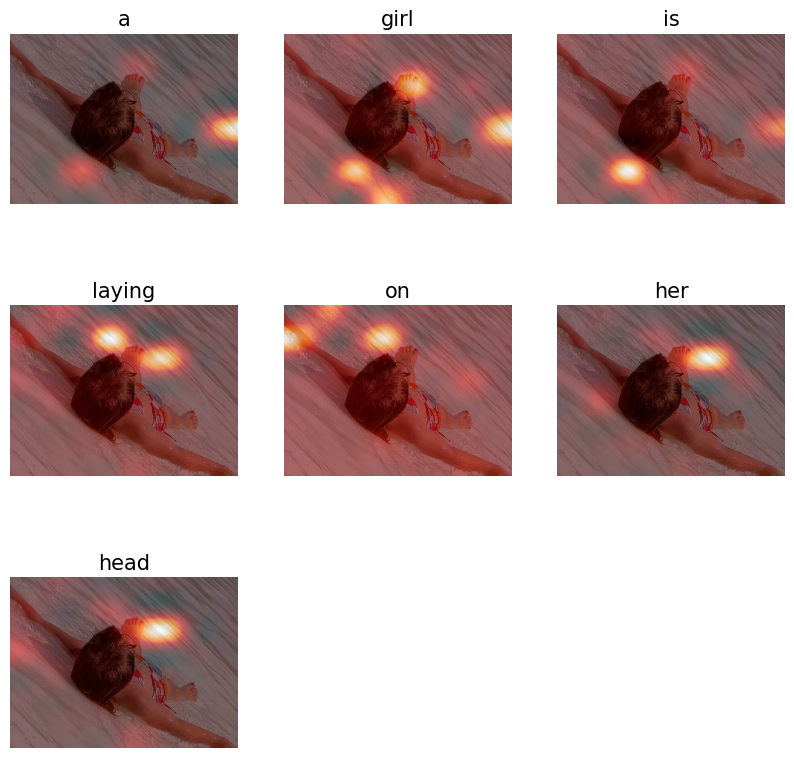

In [ ]:

#  Beam search
result = beam_evaluate(test_image, beam_index=5)



pred_caption = ' '.join(result)
pred_caption = filt_text(pred_caption)

reference = [real_caption.split()]
candidate = pred_caption.split()

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

score = sentence_bleu(
    reference,
    candidate,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)

print(f"BLEU score: {score*100}")
print('Real Caption:', real_caption)
print('Prediction Caption:', pred_caption)

plot_attmap(result, attention_plot, test_image)
